# Dataset

The original data is extracted from a real-world urban logistics scenario (Beijing, Jingdong Logistics):

- 1 depot + 99 customers = 100 locations.

- For every city-pair (i, j), the travel time is queried from a mapping API (Baidu Maps) every two hours for a 24-hour period.

- This is a time-dependent city-to-city traffic matrix for 100 cities, sampled every two hours, designed for deep RL-based route planning in dynamic environments—the foundation for benchmarking DTSP algorithms and evaluating solutions against realistic urban traffic

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Load traffic data
traffic_data = np.loadtxt('data.csv', delimiter=',')
traffic_data

array([[0.      , 0.      , 0.      , ..., 0.      , 0.      , 0.      ],
       [0.046412, 0.044711, 0.036019, ..., 0.030602, 0.026331, 0.028692],
       [0.069838, 0.041377, 0.03566 , ..., 0.043322, 0.032396, 0.036354],
       ...,
       [0.031146, 0.031354, 0.035995, ..., 0.029641, 0.028287, 0.027766],
       [0.022396, 0.020613, 0.018843, ..., 0.018623, 0.0161  , 0.0164  ],
       [0.      , 0.      , 0.      , ..., 0.      , 0.      , 0.      ]])

Structure
- Rows: Each row encodes the travel times from one city (i) to another city (j) at different times of day.Since there are 100 cities, you get a complete traffic matrix (100 × 100 = 10,000 pairs).

* Columns: Each column is a 2-hour interval (midnight, 2am, ..., 10pm), giving you 12 bins per day. So, entry (i, j, t) is the travel time from node i to node j if the salesman leaves i at time t.

* Values: These are normalized travel times (e.g., minutes or scaled units), possibly including realistic effects of congestion, edge case handling, and noise.

In [11]:
print(f"Shape: {traffic_data.shape}")

Shape: (10000, 12)


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("data.csv", header=None)

# Basic info
print("Shape:", df.shape)
print("First 10 rows:\n", df.head(10))




Shape: (10000, 12)
First 10 rows:
          0         1         2         3         4         5         6   \
0  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1  0.046412  0.044711  0.036019  0.035775  0.034109  0.050162  0.032789   
2  0.069838  0.041377  0.035660  0.037755  0.036157  0.046620  0.035451   
3  0.141644  0.118912  0.101053  0.103738  0.109444  0.122882  0.099479   
4  0.042153  0.042002  0.044051  0.041065  0.041366  0.044525  0.042720   
5  0.002894  0.002859  0.002917  0.002917  0.002882  0.003021  0.002986   
6  0.058692  0.055741  0.045949  0.044560  0.047963  0.058924  0.048333   
7  0.051204  0.050197  0.042639  0.042396  0.045602  0.058032  0.044977   
8  0.040752  0.041146  0.042014  0.039699  0.040162  0.043449  0.041481   
9  0.063900  0.045787  0.034884  0.033762  0.032407  0.049306  0.032130   

         7         8         9         10        11  
0  0.000000  0.000000  0.000000  0.000000  0.000000  
1  0.035856  0.027431  0.030602

In [13]:
print("Statistics by column:\n", df.describe())

Statistics by column:
                  0             1             2             3             4   \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean       0.047255      0.039891      0.033551      0.034888      0.036963   
std        0.022621      0.018606      0.015829      0.016478      0.018044   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.030718      0.026701      0.023342      0.024138      0.024988   
50%        0.045683      0.038333      0.032188      0.033438      0.035376   
75%        0.061403      0.051201      0.041250      0.043140      0.045880   
max        0.170694      0.125532      0.119213      0.122836      0.136528   

                 5             6             7             8             9   \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean       0.045689      0.034839      0.035113      0.028595      0.028802   
std        0.019443      0.0

In [14]:
# Find all rows where all elements are zero
zero_rows = (df == 0).all(axis=1)
num_zero_rows = zero_rows.sum()
zero_row_indices = zero_rows[zero_rows].index.tolist()

print(f"Number of all-zero rows: {num_zero_rows}")


Number of all-zero rows: 100


In [15]:
print(f"First 10 indices of all-zero rows: {zero_row_indices[:10]}")

First 10 indices of all-zero rows: [0, 101, 202, 303, 404, 505, 606, 707, 808, 909]


There are exactly 100 rows in the dataset where all values are zero. These correspond to self-loops (i.e., traveling from city 
i
i to city 
i
i), which are unused or invalid in TSP routing. For 100 cities, that means one such row for each city

In [17]:
# Analyze time slices
time_stats = df.agg(['mean','std','min','max']).transpose()
print("\nTime slice stats (mean/var):\n", time_stats)


Time slice stats (mean/var):
         mean       std  min       max
0   0.047255  0.022621  0.0  0.170694
1   0.039891  0.018606  0.0  0.125532
2   0.033551  0.015829  0.0  0.119213
3   0.034888  0.016478  0.0  0.122836
4   0.036963  0.018044  0.0  0.136528
5   0.045689  0.019443  0.0  0.126134
6   0.034839  0.016379  0.0  0.117650
7   0.035113  0.016222  0.0  0.114606
8   0.028595  0.014475  0.0  0.107130
9   0.028802  0.015080  0.0  0.112350
10  0.027231  0.014048  0.0  0.105058
11  0.029213  0.016593  0.0  0.141481


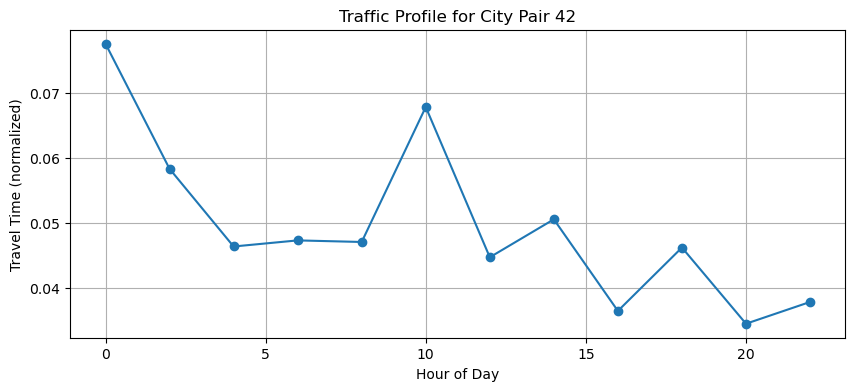

In [18]:
# Visualize a city pair's daily profile (example: row 42)
plt.figure(figsize=(10,4))
plt.plot(np.arange(df.shape[1])*2, df.iloc[42], marker='o')
plt.xlabel("Hour of Day")
plt.ylabel("Travel Time (normalized)")
plt.title("Traffic Profile for City Pair 42")
plt.grid()
plt.show()

In [19]:

# Row variance to identify dynamic/static pairs
row_variance = df.var(axis=1)
print("Most dynamic pair index:", row_variance.idxmax())
print("Most static pair index:", row_variance.idxmin())
print("Most dynamic row:\n", df.iloc[row_variance.idxmax()])
print("Most static row:\n", df.iloc[row_variance.idxmin()])



Most dynamic pair index: 5224
Most static pair index: 0
Most dynamic row:
 0     0.119201
1     0.051030
2     0.042905
3     0.046262
4     0.045706
5     0.059641
6     0.038993
7     0.037662
8     0.033831
9     0.024641
10    0.023588
11    0.030810
Name: 5224, dtype: float64
Most static row:
 0     0.0
1     0.0
2     0.0
3     0.0
4     0.0
5     0.0
6     0.0
7     0.0
8     0.0
9     0.0
10    0.0
11    0.0
Name: 0, dtype: float64


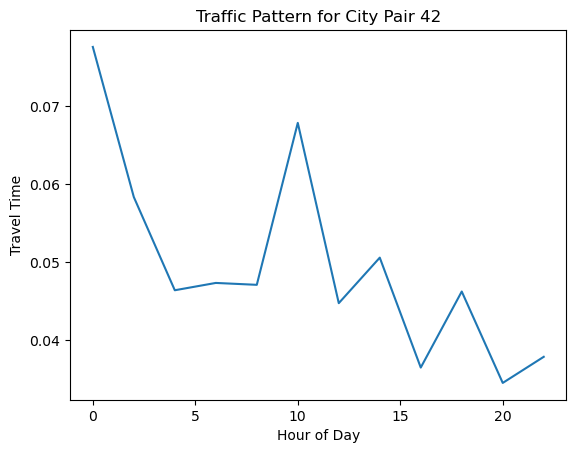

In [20]:
# Visualize traffic patterns for a specific city pair
city_pair_idx = 42  # Example city pair
times = np.arange(12) * 2  # 0, 2, 4, ..., 22 hours
plt.plot(times, traffic_data[city_pair_idx])
plt.title(f'Traffic Pattern for City Pair {city_pair_idx}')
plt.xlabel('Hour of Day')
plt.ylabel('Travel Time')
plt.show()

In [21]:
avg_by_time = df.mean(axis=0)

# Rush hours: time bins with highest mean
rush_hour_indices = np.where(avg_by_time == avg_by_time.max())[0]
rush_time_hours = [i*2 for i in rush_hour_indices]
print(f"Rush hour bins: {rush_time_hours} (in hours, where time bin width = 2h)")

# To see the top 3 busiest bins:
top3_idx = avg_by_time.nlargest(3).index.tolist()
top3_hours = [i*2 for i in top3_idx]
print(f"Top 3 traffic bins: {top3_hours} hours")

Rush hour bins: [0] (in hours, where time bin width = 2h)
Top 3 traffic bins: [0, 10, 2] hours


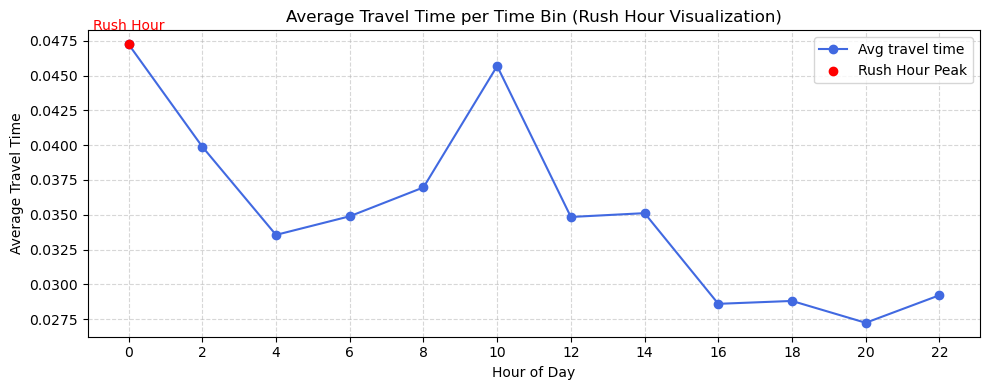

In [22]:
# Compute average travel time for each time bin
avg_by_time = df.mean(axis=0)
time_bins = np.arange(df.shape[1]) * 2  # Assuming 2-hour bins: 0, 2, ..., 22

# Plot the line chart
plt.figure(figsize=(10, 4))
plt.plot(time_bins, avg_by_time, marker='o', color='royalblue', label='Avg travel time')

# Highlight rush hour (peak)
rush_hour_idx = avg_by_time.idxmax()
rush_hour_time = time_bins[rush_hour_idx]
plt.scatter([rush_hour_time], [avg_by_time[rush_hour_idx]], color='red', zorder=5, label='Rush Hour Peak')
plt.annotate('Rush Hour', (rush_hour_time, avg_by_time[rush_hour_idx]),
             textcoords="offset points", xytext=(0,10), ha='center', color='red')

plt.title('Average Travel Time per Time Bin (Rush Hour Visualization)')
plt.xlabel('Hour of Day')
plt.ylabel('Average Travel Time')
plt.xticks(time_bins)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


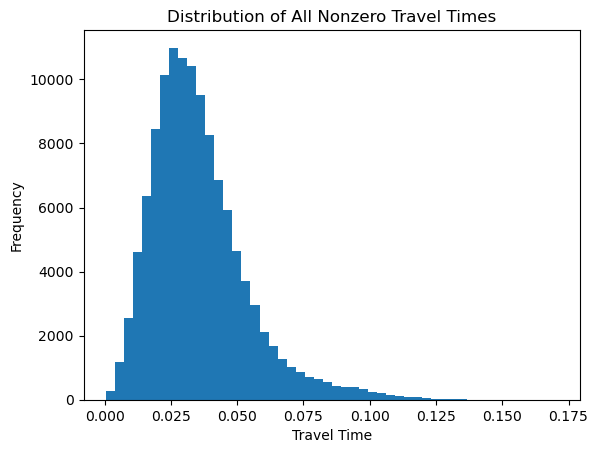

In [ ]:
import matplotlib.pyplot as plt
travel_times = df.values.flatten()
travel_times_nonzero = travel_times[travel_times > 0] # exclude zero values
plt.hist(travel_times_nonzero, bins=50)
plt.title('Distribution of All Nonzero Travel Times')
plt.xlabel('Travel Time')
plt.ylabel('Frequency')
plt.show()


In [24]:
# 3. Pairwise Min/Max Stats
row_min = df.min(axis=1)
row_max = df.max(axis=1)
print("\nStats for min travel times per pair:\n", row_min.describe())
print("\nStats for max travel times per pair:\n", row_max.describe())



Stats for min travel times per pair:
 count    10000.000000
mean         0.026974
std          0.014049
min          0.000000
25%          0.018576
50%          0.025243
75%          0.032720
max          0.105058
dtype: float64

Stats for max travel times per pair:
 count    10000.000000
mean         0.050734
std          0.022280
min          0.000000
25%          0.035772
50%          0.050330
75%          0.063368
max          0.170694
dtype: float64


In [25]:
# 4. Count static and highly dynamic pairs
static_pairs = np.sum(np.isclose(row_min, row_max, atol=1e-4))
dynamic_pairs = np.sum((row_max / row_min.replace(0, np.nan)) > 2)  # avoid zero-divide
print(f"\n# Static (min≈max): {static_pairs}   # Highly Dynamic (max/min > 2): {dynamic_pairs}")



# Static (min≈max): 100   # Highly Dynamic (max/min > 2): 4143


Out of 10,000 total city-to-city pairs in your dataset, 4,143 pairs have the property that their worst-case travel time is at least twice as large as their best-case travel time.

How is it calculated?

For each city pair (row):

Calculate the minimum travel time (min), which is the fastest possible trip for that pair over the day.

Calculate the maximum travel time (max), which is the slowest possible trip for that pair over the day.

Compute the ratio max/min.

If this ratio is greater than 2 (more than twice long), that pair is considered "highly dynamic" or "highly affected by traffic timing."

Example: If from City 1 to City 2 takes 10 mins at midnight (min), but 25 mins at 5pm (max), the ratio is 2.5 (> 2, so highly dynamic).

4143 is out of 10,000

In [26]:
# 5. Most/least dynamic pairs
row_var = df.var(axis=1)
most_dynamic_idx = row_var.idxmax()
least_dynamic_idx = row_var.idxmin()
print(f"\nMost dynamic row index: {most_dynamic_idx}   Least dynamic row index: {least_dynamic_idx}")




Most dynamic row index: 5224   Least dynamic row index: 0


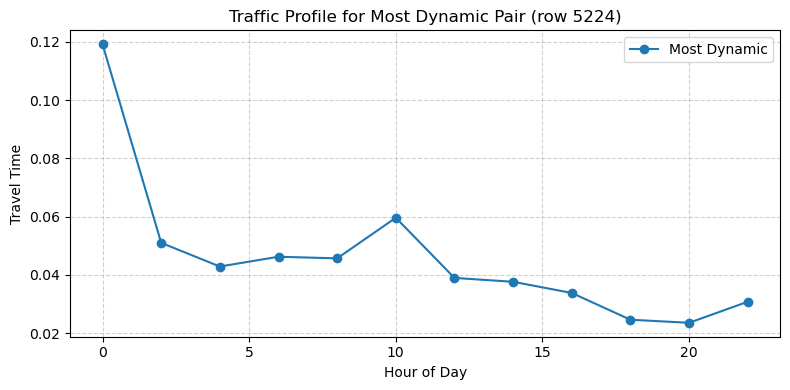

In [27]:
plt.figure(figsize=(8,4))
plt.plot(np.arange(df.shape[1])*2, df.iloc[most_dynamic_idx], marker='o', label='Most Dynamic')
plt.title(f'Traffic Profile for Most Dynamic Pair (row {most_dynamic_idx})')
plt.xlabel('Hour of Day')
plt.ylabel('Travel Time')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('most_dynamic_profile.png')
plt.legend()
plt.show()




In [28]:
# 6. Bin-to-bin correlation
corr = df.corr()
print("\nTime bin correlations:\nMean:", corr.values.mean(), "Min:", corr.values.min(), "Max:", corr.values.max())




Time bin correlations:
Mean: 0.935446925282739 Min: 0.8076858711394165 Max: 1.0



Outlier thresholds (IQR): lower=-0.00842 upper=0.07579
# Outlier values (outside IQR bounds): 4321


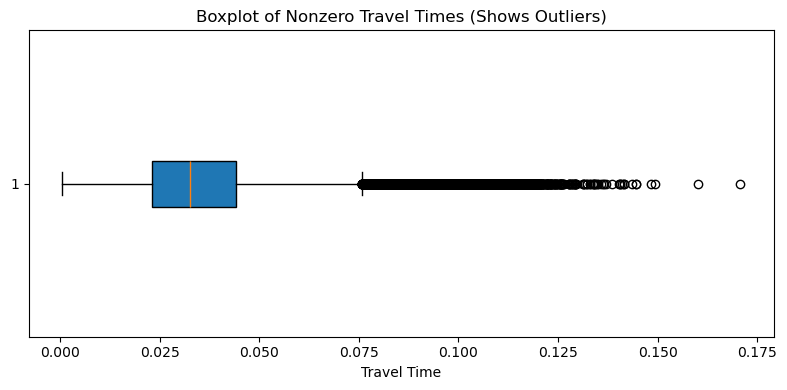

In [29]:
# 7. Outlier detection (global travel times)
# Upper/lower bounds for outliers (Z >= 3)
q1, q3 = np.percentile(travel_times_nonzero, [25, 75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_indices = np.where((travel_times_nonzero < lower_bound) | (travel_times_nonzero > upper_bound))[0]
print(f"\nOutlier thresholds (IQR): lower={lower_bound:.5f} upper={upper_bound:.5f}")
print(f"# Outlier values (outside IQR bounds): {len(outlier_indices)}")

plt.figure(figsize=(8,4))
plt.boxplot(travel_times_nonzero, vert=False, patch_artist=True)
plt.title('Boxplot of Nonzero Travel Times (Shows Outliers)')
plt.xlabel('Travel Time')
plt.tight_layout()
plt.savefig('travel_time_boxplot.png')
plt.show()

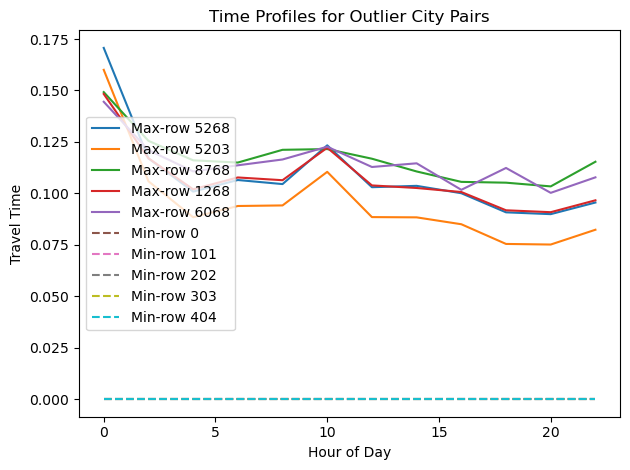

In [30]:
# 8. Outlier profiles (by pair): show a few extreme cases
top5_max = row_max.nlargest(5).index
top5_min = row_min.nsmallest(5).index
for idx in top5_max:
    plt.plot(np.arange(df.shape[1])*2, df.iloc[idx], label=f'Max-row {idx}')
for idx in top5_min:
    plt.plot(np.arange(df.shape[1])*2, df.iloc[idx], linestyle='--', label=f'Min-row {idx}')

plt.title('Time Profiles for Outlier City Pairs')
plt.xlabel('Hour of Day')
plt.ylabel('Travel Time')
plt.legend()
plt.tight_layout()
plt.savefig('outlier_profiles.png')
plt.show()

How is it usually done?
Step 1: Train your model as usual (on the complete dataset).

Step 2: For evaluation, partition your test set, or tour steps, into:

“Regular” (not outlier) pairs/times

“Outlier” (highest max/min ratio, highest variance, or values beyond some threshold)

Step 3: Report separate metrics:

Average performance overall

Performance only on the outliers (does the model still succeed on the hardest cases?)

Why is this useful?
It reveals whether your method generalizes or fails catastrophically on edge cases.

It also shows reviewers/readers that you understand and address the most critical, business-relevant or risk-prone routing scenarios.